In [1]:
import nibabel as nib
import numpy as np
import torch
import glob
import os

def load_brats_case(case_folder, modalities=("t1ce","t2","flair")):
    """
    Loads a BraTS case and returns tensor [1,3,D,H,W]
    """

    vols = []

    for mod in modalities:
        f = glob.glob(os.path.join(case_folder, f"*_{mod}.nii*"))
        if len(f) == 0:
            raise ValueError(f"Missing modality {mod} in {case_folder}")

        nii = nib.load(f[0])
        vol = nii.get_fdata().astype(np.float32)

        vol = (vol - vol.min()) / (vol.max() - vol.min() + 1e-6)

        vols.append(vol)

    vols = np.stack(vols, axis=0)

    vols = vols[None]

    return torch.tensor(vols, dtype=torch.float32)

In [2]:
import os

for root, dirs, files in os.walk("/Users/apple/Desktop/BRAINIAC"):
    for f in files:
        if f.endswith(".nii") or f.endswith(".nii.gz"):
            print(os.path.join(root, f))
            break
        

/Users/apple/Desktop/BRAINIAC/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_069/BraTS20_Validation_069_flair.nii
/Users/apple/Desktop/BRAINIAC/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_056/BraTS20_Validation_056_flair.nii
/Users/apple/Desktop/BRAINIAC/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_051/BraTS20_Validation_051_flair.nii
/Users/apple/Desktop/BRAINIAC/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_058/BraTS20_Validation_058_t1ce.nii
/Users/apple/Desktop/BRAINIAC/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_093/BraTS20_Validation_093_t1ce.nii
/Users/apple/Desktop/BRAINIAC/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_067/BraTS20_Validation_067_t2.nii
/Users/apple/Desktop/BRAINIAC/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData/BraTS20_Validation_060/BraTS20_Validation_060_t1ce.nii
/User

In [3]:
import torch
from monai.networks.nets import SwinUNETR

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = SwinUNETR(
    in_channels=3,
    out_channels=2,
    feature_size=12,
    use_checkpoint=False
).to(device)

model.load_state_dict(
    torch.load("/Users/apple/Desktop/BRAINIAC/models/best_swin_unetr.pt",
               map_location=device)
)

model.eval()
print("✅ Model ready for counterfactuals")

✅ Model ready for counterfactuals


In [4]:
import nibabel as nib
import numpy as np
import torch

def load_sample(path, normalize=True):
    """
    Loads NIfTI MRI and returns tensor [1, C, D, H, W]
    Works with 1 or multi-channel volumes.
    """

    nii = nib.load(path)
    vol = nii.get_fdata().astype(np.float32)

    if vol.ndim == 3:
        vol = vol[None]   

    if normalize:
        vol = (vol - vol.min()) / (vol.max() - vol.min() + 1e-6)

    vol = vol[None]       

    return torch.tensor(vol, dtype=torch.float32)

In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model.eval()

x = load_brats_case(
    "/Users/apple/Desktop/BRAINIAC/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_032"
)

x = x.to(device)
x.requires_grad_(True)

print("Loaded:", x.shape)
x = x.to(device)

_, _, D, H, W = x.shape
size = 128
z = (D-size)//2
y = (H-size)//2
x0 = (W-size)//2
x = x[:,:,z:z+size,y:y+size,x0:x0+size]
print("After crop:", x.shape)

x = x.clone().detach().requires_grad_(True)

with torch.no_grad():
    original_pred = torch.softmax(model(x), dim=1)

Loaded: torch.Size([1, 3, 240, 240, 155])
After crop: torch.Size([1, 3, 128, 128, 128])


/Users/apple/Desktop/BRAINIAC/brainiac_env/lib/python3.10/site-packages/torch/nn/functional.py:5418: UserWarning: MPS: The constant padding of more than 3 dimensions is not currently supported natively. It uses View Ops default implementation to run. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/mps/operations/Pad.mm:476.)
  return torch._C._nn.pad(input, pad, mode, value)


In [ ]:
def counterfactual_loss(pred, original_pred, x, x_orig,
                        lam_pred=1.0,
                        lam_l2=0.05,
                        lam_smooth=0.02):

    tumor_prob = torch.softmax(pred, dim=1)[:,1]
    loss_pred = tumor_prob.mean()

    loss_l2 = torch.norm(x - x_orig)

    dz = torch.mean(torch.abs(x[:,:,1:] - x[:,:,:-1]))
    dy = torch.mean(torch.abs(x[:,:,:,1:] - x[:,:,:,:-1]))
    dx = torch.mean(torch.abs(x[:,:,:,:,1:] - x[:,:,:,:,:-1]))

    loss_smooth = dx + dy + dz

    return lam_pred*loss_pred + lam_l2*loss_l2 + lam_smooth*loss_smooth

In [ ]:
x_orig = x.clone().detach()

optimizer = torch.optim.Adam([x], lr=0.03)

for step in range(120):

    optimizer.zero_grad()

    pred = model(x)

    loss = counterfactual_loss(pred, original_pred, x, x_orig)

    loss.backward()
    optimizer.step()

    x.data = torch.clamp(x.data, 0, 1)

    if step % 20 == 0:
        print(f"Step {step}  Loss {loss.item():.4f}")

Step 0  Loss 0.0369
Step 20  Loss 0.4856
Step 40  Loss 0.1714
Step 60  Loss 0.1333
Step 80  Loss 0.1206
Step 100  Loss 0.1198


In [17]:
counterfactual = x.detach().cpu().numpy()[0,0,64]
original = x_orig.cpu().numpy()[0,0,64]

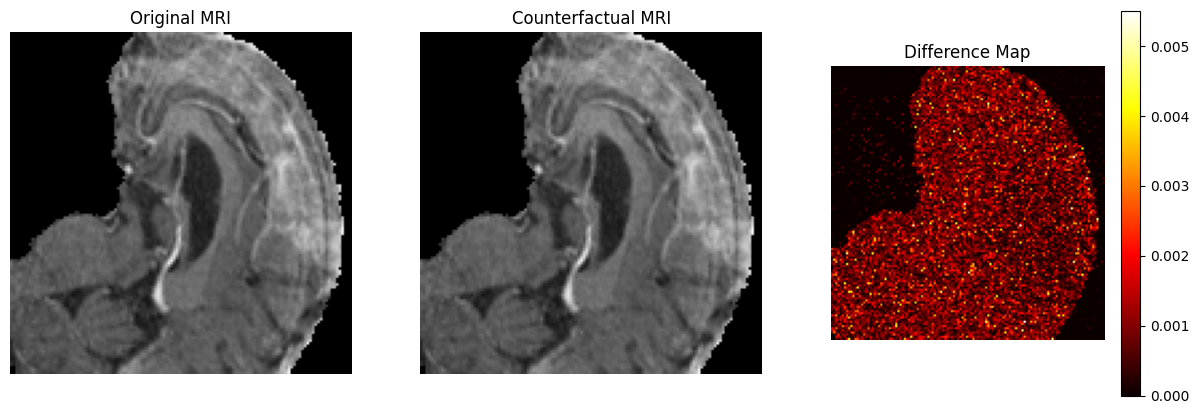

In [18]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original MRI")
plt.imshow(original, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Counterfactual MRI")
plt.imshow(counterfactual, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Difference Map")
plt.imshow(abs(counterfactual-original), cmap="hot")
plt.colorbar()
plt.axis("off")

plt.show()